In [ ]:
import os
import ollama

# ==========================================
# ★★★ 自分専用Ollama（ポート11500）に接続 ★★★
os.environ["OLLAMA_HOST"] = "http://127.0.0.1:11500"

# 【修正1】GPUを2枚とも使う設定に変更 ("0" → "0,1")
# 120B(65GB)は巨大なので、2枚のVRAMを合わせないと載り切らない、あるいは遅くなる可能性があります
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
# ==========================================

# 1. 絶対パスでファイルを指定して読み込む
file_path = "/home/sakulab/workspace/B4_ikeda/graduation_thesis/data/corpus/corpus_2024-08-05.txt"

if os.path.exists(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        text_data = f.read().strip()
    print(f"✅ ファイル読み込み成功: {len(text_data)}文字")
else:
    print(f"❌ ファイルが見つかりません: {file_path}")
    text_data = ""

# 2. 読み込みに成功したらOllamaを実行
if text_data:
    my_prompt = f"""
    あなたは金融市場に精通したベテラン経済記者です。
    以下のツイート群は、ある一日の市場参加者の生の声です。
    あなたの持つ高度な金融・経済知識をフル活用して文脈や隠れた意図を読み取り、以下の2つのタスクを行ってください。

    【タスク1：明日の予測】
    ツイート全体のセンチメント（悲観・楽観）や材料から、**翌営業日の日経平均株価**は「上がる」か「下がる」か予測し、冒頭に【上昇】または【下落】とだけ記してください。

    【タスク2：市況の要約】
    予測の根拠となる市場の雰囲気、注目された材料、投資家心理を、200文字程度の「一つの自然な日本語の文章」にまとめてください。
    ※箇条書き、見出し、体言止めは禁止です。

    入力テキスト：
    {text_data}

    あなたは金融市場に精通したベテラン経済記者です。
    以下のツイート群は、ある一日の市場参加者の生の声です。
    あなたの持つ高度な金融・経済知識をフル活用して文脈や隠れた意図を読み取り、以下の2つのタスクを行ってください。

    【タスク1：明日の予測】
    ツイート全体のセンチメント（悲観・楽観）や材料から、**翌営業日の日経平均株価**は「上がる」か「下がる」か予測し、冒頭に【上昇】または【下落】とだけ記してください。

    【タスク2：市況の要約】
    予測の根拠となる市場の雰囲気、注目された材料、投資家心理を、200文字程度の「一つの自然な日本語の文章」にまとめてください。
    ※箇条書き、見出し、体言止めは禁止です。
    """

    print("🚀 120Bモデルで生成を開始します... (時間がかかる場合があります)")
    
    try:
        response = ollama.chat(
            model="gpt-oss:120b",
            messages=[{"role": "user", "content": my_prompt}],
            options={
                "temperature": 0,    # ランダム性を排除
                "seed": 42,          # 乱数の種を固定（完全再現用）
                "num_ctx": 131072      # ★重要！ 一度に読める量を増やす（デフォルトは2048）
            }
        )
        # responseの後にこれを追加
        print(f"実読み込みトークン数 (Prompt): {response.get('prompt_eval_count')}")
        print(f"生成トークン数 (Response): {response.get('eval_count')}")
        print("\n=== 生成結果 (120B) ===")
        print(response["message"]["content"])
        print("========================")
        
    except Exception as e:
        print(f"エラーが発生しました: {e}")

✅ ファイル読み込み成功: 1922542文字
🚀 120Bモデルで生成を開始します... (時間がかかる場合があります)
実読み込みトークン数 (Prompt): 131072
生成トークン数 (Response): 882

=== 生成結果 (120B) ===
【上昇】昨日の史上最大級の下落で投資家はパニック売りに走り含み損が拡大したが、米国のISM非製造業指数が予想を上回り円安基調が続く中、日経先物は約2千円上昇している。市場は売り過剰感からの自律反発を期待しつつ、追証や空売り返済の影響で変動は続くものの、明日は小幅上昇が見込まれる。


In [8]:
import os
import glob
from tqdm import tqdm  # 進捗バーを表示するライブラリ（もし入ってなければ pip install tqdm）

# データ置き場
INPUT_DIR = "/home/sakulab/workspace/B4_ikeda/graduation_thesis/data/corpus/"

print(f"📂 フォルダをスキャン中: {INPUT_DIR}")

# ファイル一覧を取得
files = glob.glob(os.path.join(INPUT_DIR, "*.txt"))

if not files:
    print("❌ ファイルが見つかりませんでした。パスを確認してください。")
    exit()

max_char_count = 0
max_file = ""
total_files = len(files)

print(f"🚀 {total_files} 件のファイルをチェックします...")

# 全ファイルをループして文字数を数える
# (tqdmを使うと進捗バーが出ます。なければ for file_path in files: だけでOK)
for file_path in tqdm(files):
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read().strip()
            char_count = len(text)
            
            # チャンピオン更新なら記録
            if char_count > max_char_count:
                max_char_count = char_count
                max_file = file_path
                
    except Exception as e:
        print(f"⚠️ 読み込みエラー: {file_path} ({e})")

# === 結果発表 ===
if max_file:
    filename = os.path.basename(max_file)
    print("\n" + "="*40)
    print(f"👑 文字数チャンピオン: {filename}")
    print(f"📊 文字数: {max_char_count:,} 文字")
    
    # トークン数の概算 (日本語は 1文字 ≈ 0.8〜1.2トークン換算が安全圏)
    # ※Llama系トークナイザーでのざっくり試算
    estimated_tokens = int(max_char_count * 1.1) 
    
    print(f"🔢 推定トークン数: 約 {estimated_tokens:,} tokens")
    print("="*40)

    # 判定
    limit = 32768
    if estimated_tokens > limit:
        print(f"🚨 警告: 設定値 (num_ctx: {limit}) を超えている可能性があります！")
        print(f"   あと {estimated_tokens - limit:,} トークン分、枠を広げるか、データを削る必要があります。")
    else:
        print(f"✅ 安心してください。設定値 ({limit}) に収まりそうです。")
        print(f"   (余裕: 約 {limit - estimated_tokens:,} tokens)")

else:
    print("ファイルの中身が空でした。")
    

📂 フォルダをスキャン中: /home/sakulab/workspace/B4_ikeda/graduation_thesis/data/corpus/
🚀 2680 件のファイルをチェックします...


100%|██████████| 2680/2680 [00:00<00:00, 4331.47it/s]


👑 文字数チャンピオン: corpus_2024-08-05.txt
📊 文字数: 1,922,542 文字
🔢 推定トークン数: 約 2,114,796 tokens
🚨 警告: 設定値 (num_ctx: 32768) を超えている可能性があります！
   あと 2,082,028 トークン分、枠を広げるか、データを削る必要があります。


In [1]:
import os
import glob
import numpy as np
from transformers import AutoTokenizer
from tqdm import tqdm

# ==========================================
# ★ 設定エリア ★
# ==========================================
# 調査対象のフォルダ
INPUT_DIR = "/home/sakulab/workspace/B4_ikeda/graduation_thesis/data/summary_full_v1/"

# 診断に使うモデルのトークナイザー（今、一番有力なGLuCoSEで測ります）
MODEL_NAME = "pkshatech/GLuCoSE-base-ja"
# MODEL_NAME = "intfloat/multilingual-e5-large" # E5で測りたい場合はこちら

# 許容限界（これを超えると切り捨てられる）
LIMIT = 512 
# ==========================================

def check_tokens():
    print(f"🔍 トークン数チェック開始: {MODEL_NAME}")
    
    # トークナイザーのロード
    try:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    except Exception as e:
        print(f"❌ トークナイザーの読み込みに失敗しました: {e}")
        return

    # ファイル一覧取得
    files = sorted(glob.glob(os.path.join(INPUT_DIR, "summary_*.txt")))
    if not files:
        print("❌ ファイルが見つかりません。パスを確認してください。")
        return

    token_counts = []
    over_limit_files = []

    print(f"📂 対象ファイル数: {len(files)} 件")
    print("⏳ 計測中...")

    for file_path in tqdm(files):
        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read().strip()
        
        if not text:
            continue
            
        # トークン化して長さを測る
        # (add_special_tokens=True なので [CLS] [SEP] などの特殊トークンも含む正確な数)
        tokens = tokenizer.encode(text, add_special_tokens=True)
        length = len(tokens)
        
        token_counts.append(length)
        
        if length > LIMIT:
            over_limit_files.append((os.path.basename(file_path), length))

    # === 結果発表 ===
    token_counts = np.array(token_counts)
    
    print("\n" + "="*40)
    print("📊 トークン数 統計レポート")
    print("="*40)
    print(f"✅ 平均 (Mean)   : {np.mean(token_counts):.1f}")
    print(f"✅ 中央値 (Median): {np.median(token_counts):.1f}")
    print(f"📈 最大 (Max)    : {np.max(token_counts)}")
    print(f"📉 最小 (Min)    : {np.min(token_counts)}")
    print("-" * 40)
    
    over_count = len(over_limit_files)
    ratio = over_count / len(files) * 100
    
    if over_count == 0:
        print(f"🎉 素晴らしい！ 全て {LIMIT} トークン以内に収まっています。")
    else:
        print(f"⚠️ 注意！ {over_count} 件 ({ratio:.1f}%) が {LIMIT} トークンを超えています。")
        print(f"   → これらは末尾がカットされています。")
        
        # ワースト5を表示
        print("\n💀 ワースト5 (長すぎるファイル):")
        over_limit_files.sort(key=lambda x: x[1], reverse=True)
        for name, length in over_limit_files[:5]:
            print(f"   - {name}: {length} tokens")

if __name__ == "__main__":
    check_tokens()

/home/sakulab/workspace/B4_ikeda/graduation_thesis/ollama_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔍 トークン数チェック開始: pkshatech/GLuCoSE-base-ja
📂 対象ファイル数: 2680 件
⏳ 計測中...


100%|██████████| 2680/2680 [00:00<00:00, 3780.88it/s]


📊 トークン数 統計レポート
✅ 平均 (Mean)   : 76.6
✅ 中央値 (Median): 75.0
📈 最大 (Max)    : 200
📉 最小 (Min)    : 40
----------------------------------------
🎉 素晴らしい！ 全て 512 トークン以内に収まっています。


🕵️ 疑惑の検証開始: GLuCoSE (Acc 67% Model)
🏋️ 再学習中...
🧪 推論実行中...
📊 再現Accuracy: 59.52%
              precision    recall  f1-score   support

          下落       0.58      0.61      0.60        41
          上昇       0.61      0.58      0.60        43

    accuracy                           0.60        84
   macro avg       0.60      0.60      0.60        84
weighted avg       0.60      0.60      0.60        84

🖼️ 画像保存完了: /home/sakulab/workspace/B4_ikeda/graduation_thesis/result/verification_GLuCoSE.png
→ この画像をダウンロードして確認してください！


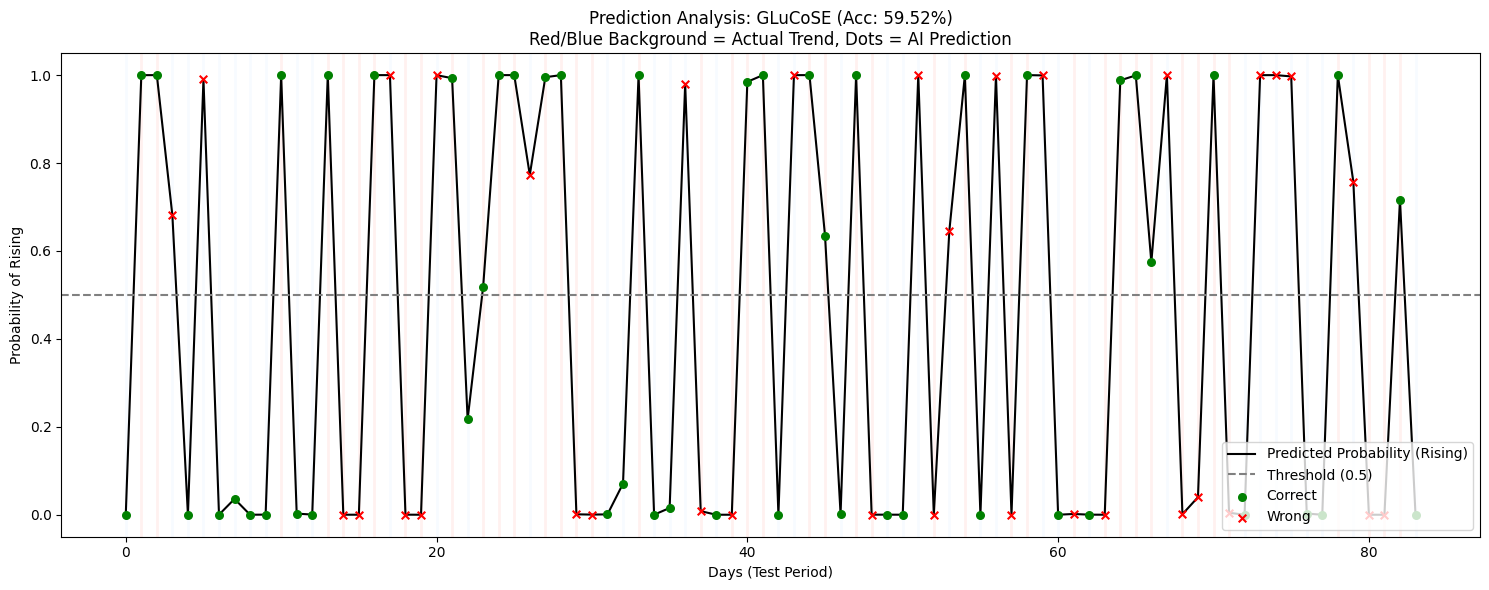

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# ★ 疑惑の優勝パラメータを入力 ★
# ==========================================
PARAMS = {
    "SEQUENCE_LENGTH": 40,
    "HIDDEN_SIZE":     64,
    "DROPOUT":         0.5,
    "EPOCHS":          100,
    "BATCH_SIZE":      32
}

MODEL_NAME = "GLuCoSE" # 優勝モデル
VECTOR_FILE = "/home/sakulab/workspace/B4_ikeda/graduation_thesis/data/vectors/vectors_GLuCoSE.pkl"
# ==========================================

# 期間設定
TRAIN_START = "2017-08-31"
TRAIN_END   = "2024-06-30"
TEST_START  = "2024-07-01"
TEST_END    = "2024-12-31"

FINANCE_CSV = "/home/sakulab/workspace/B4_ikeda/graduation_thesis/data/finance/nikkei_225_labeled.csv"
RESULT_IMG  = f"/home/sakulab/workspace/B4_ikeda/graduation_thesis/result/verification_{MODEL_NAME}.png"

# LSTM定義
class HybridLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(HybridLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.sigmoid(self.fc(out[:, -1, :]))

def visualize():
    print(f"🕵️ 疑惑の検証開始: {MODEL_NAME} (Acc 67% Model)")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # 1. データ準備
    df_vectors = pd.read_pickle(VECTOR_FILE)
    df_finance = pd.read_csv(FINANCE_CSV)
    df = pd.merge(df_finance, df_vectors, on="Date_Str", how="inner").sort_values("Date_Str")
    
    # 期間分割
    df_train = df[(df["Date_Str"] >= TRAIN_START) & (df["Date_Str"] <= TRAIN_END)].copy()
    df_test  = df[(df["Date_Str"] >= TEST_START) & (df["Date_Str"] <= TEST_END)].copy()
    
    # 正規化
    scaler = MinMaxScaler()
    scaler.fit(df_train[["Close", "Volume"]])
    df_train[["Close_Scaled", "Volume_Scaled"]] = scaler.transform(df_train[["Close", "Volume"]])
    df_test[["Close_Scaled", "Volume_Scaled"]]  = scaler.transform(df_test[["Close", "Volume"]])

    # データセット作成
    def create_dataset(df_local, seq_len):
        vector_features = np.stack(df_local["Vector"].values)
        numeric_features = df_local[["Close_Scaled", "Volume_Scaled"]].values
        combined = np.hstack([vector_features, numeric_features])
        labels = df_local["Actual_Label"].values
        dates = df_local["Date_Str"].values[seq_len:] # 日付も保持
        
        X, y = [], []
        for i in range(len(df_local) - seq_len):
            X.append(combined[i : i + seq_len])
            y.append(labels[i + seq_len])
        return np.array(X), np.array(y), dates

    seq_len = PARAMS["SEQUENCE_LENGTH"]
    X_train, y_train, _ = create_dataset(df_train, seq_len)
    X_test, y_test, test_dates = create_dataset(df_test, seq_len)
    
    # 学習
    print("🏋️ 再学習中...")
    loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                                      torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)), 
                        batch_size=PARAMS["BATCH_SIZE"], shuffle=True)
    
    input_size = X_train.shape[2]
    model = HybridLSTM(input_size, PARAMS["HIDDEN_SIZE"], 2, PARAMS["DROPOUT"]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()
    
    model.train()
    for epoch in range(PARAMS["EPOCHS"]):
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            
    # 推論
    print("🧪 推論実行中...")
    model.eval()
    with torch.no_grad():
        inputs = torch.tensor(X_test, dtype=torch.float32).to(device)
        probs = model(inputs).cpu().numpy().flatten()
    
    preds = (probs >= 0.5).astype(int)
    acc = accuracy_score(y_test, preds)
    print(f"📊 再現Accuracy: {acc:.2%}")
    print(classification_report(y_test, preds, target_names=["下落", "上昇"]))
    
    # === グラフ描画 ===
    plt.figure(figsize=(15, 6))
    
    # 正解データのプロット（背景色で表現）
    # 上昇=赤, 下落=青 の帯を引く
    for i in range(len(y_test)):
        color = "mistyrose" if y_test[i] == 1 else "aliceblue"
        plt.axvline(x=i, color=color, linewidth=2, alpha=0.5, ymin=0, ymax=1)
    
    # 予測確率のプロット
    plt.plot(probs, color="black", linewidth=1.5, label="Predicted Probability (Rising)")
    plt.axhline(y=0.5, color="gray", linestyle="--", label="Threshold (0.5)")
    
    # 正解・不正解のマーク
    correct_indices = [i for i in range(len(y_test)) if y_test[i] == preds[i]]
    incorrect_indices = [i for i in range(len(y_test)) if y_test[i] != preds[i]]
    
    plt.scatter(correct_indices, probs[correct_indices], color="green", s=30, label="Correct", zorder=5)
    plt.scatter(incorrect_indices, probs[incorrect_indices], color="red", s=30, marker="x", label="Wrong", zorder=5)
    
    plt.title(f"Prediction Analysis: {MODEL_NAME} (Acc: {acc:.2%})\nRed/Blue Background = Actual Trend, Dots = AI Prediction")
    plt.xlabel("Days (Test Period)")
    plt.ylabel("Probability of Rising")
    plt.legend(loc="lower right")
    plt.tight_layout()
    
    plt.savefig(RESULT_IMG)
    print(f"🖼️ 画像保存完了: {RESULT_IMG}")
    print("→ この画像をダウンロードして確認してください！")

if __name__ == "__main__":
    visualize()

In [ ]:
import os
import glob
import pandas as pd
from datetime import datetime
import math

# ==========================================
# ★ 設定エリア ★
# ==========================================
# データの場所
DATA_DIR = "/home/sakulab/workspace/B4_ikeda/graduation_thesis/data/summary_reasoning_v1/"

# 比較対象の正解データ（営業日リストとして使用）
MARKET_CSV = "/home/sakulab/workspace/B4_ikeda/graduation_thesis/data/finance/market_data_all_labeled.csv"

# チェックしたい期間
CHECK_START = "2017-09-01"
CHECK_END   = "2024-12-31"
# ==========================================

def main():
    print(f"🔍 データチェックを開始します...")
    print(f"📂 対象ディレクトリ: {DATA_DIR}")
    print("-" * 50)

    # 1. 生成されたファイルの一覧を取得
    files = sorted(glob.glob(os.path.join(DATA_DIR, "summary_*.txt")))
    
    if not files:
        print("❌ ファイルが1つも見つかりません！パスを確認してください。")
        return

    # ------------------------------------------------
    # 🕒 A. かかった時間の計算 (ファイルの更新日時から算出)
    # ------------------------------------------------
    first_file = files[0]
    last_file = files[-1]
    
    # タイムスタンプ取得
    start_time = os.path.getmtime(first_file)
    end_time = os.path.getmtime(last_file)
    
    total_seconds = end_time - start_time
    hours = int(total_seconds // 3600)
    minutes = int((total_seconds % 3600) // 60)
    
    print(f"⏱️ 推定処理時間")
    print(f"   開始: {datetime.fromtimestamp(start_time).strftime('%Y-%m-%d %H:%M:%S')} ({os.path.basename(first_file)})")
    print(f"   終了: {datetime.fromtimestamp(end_time).strftime('%Y-%m-%d %H:%M:%S')} ({os.path.basename(last_file)})")
    print(f"   👉 合計: {hours}時間 {minutes}分 ({total_seconds:.0f}秒)")
    print("-" * 50)

    # ------------------------------------------------
    # 📅 B. 欠損チェック (市場データとの突き合わせ)
    # ------------------------------------------------
    print(f"📊 欠損データのチェック ({CHECK_START} 〜 {CHECK_END})")
    
    # 市場データの読み込み
    if not os.path.exists(MARKET_CSV):
        print(f"❌ 市場データが見つかりません: {MARKET_CSV}")
        return

    df = pd.read_csv(MARKET_CSV)
    df['Date_Str'] = pd.to_datetime(df['Date_Str'])
    df.set_index('Date_Str', inplace=True)
    
    # 期間内の営業日を抽出
    target_dates = df.loc[CHECK_START:CHECK_END].index
    total_days = len(target_dates)
    
    missing_dates = []
    existing_files = []

    for date_obj in target_dates:
        date_str = date_obj.strftime('%Y-%m-%d')
        file_path = os.path.join(DATA_DIR, f"summary_{date_str}.txt")
        
        if os.path.exists(file_path):
            existing_files.append(date_str)
        else:
            missing_dates.append(date_str)

    # 結果表示
    print(f"   ✅ 生成済み: {len(existing_files)} / {total_days} 日 (進捗率: {len(existing_files)/total_days*100:.1f}%)")
    
    if len(missing_dates) == 0:
        print(f"   🎉 完璧です！期間内の全データが揃っています！")
    else:
        print(f"   ⚠️ {len(missing_dates)} 日分のデータが足りません！")
        if len(missing_dates) < 20:
            print(f"   [欠損日リスト]: {missing_dates}")
        else:
            print(f"   [欠損日リスト(先頭20件)]: {missing_dates[:20]} ...")

    print("-" * 50)

if __name__ == "__main__":
    main()